# LAB 03 - Word Representations and Embeddings

Corpus: 10.000 documents đầu tiên của C4, cùng nguồn và tokenizer với Lab 2.
Bảng in trực tiếp; biểu đồ inline. Kết quả định lượng lưu vào results.csv trong lab3.
Nhận xét là bản nháp do AI hỗ trợ; sinh viên cần tự đánh giá theo yêu cầu W3.


## Cấu hình corpus và tiền xử lý

Lowercase; tách câu theo dấu kết câu/newline; token chữ, số và dấu nháy bên trong từ.
Co-occurrence giữ vị trí token, không nối qua biên câu. OOV không tạo count nhưng vẫn chiếm vị trí trong window.
Vocabulary co-occurrence: min_count=5, top 5.000 từ cộng các từ khảo sát đủ count. Word2Vec: min_count=2, vocabulary riêng.
Không bỏ stopwords khi huấn luyện; chỉ lọc một danh sách nhỏ ở bước dẫn chứng context và lấy trung bình vector cho search.


In [1]:
from pathlib import Path
from collections import Counter
from time import perf_counter
import gc
import importlib.metadata
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

def find_lab_directory():
    current = Path.cwd().resolve()
    for parent in (current, *current.parents):
        if parent.name == "lab3" and (parent / "cooccurrence.py").is_file():
            return parent
        candidate = parent / "lab3"
        if (candidate / "cooccurrence.py").is_file():
            return candidate
    raise FileNotFoundError("Run from lab3 or a parent directory")

LAB_DIR = find_lab_directory()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))
from cooccurrence import (build_vocabulary, build_cooccurrence_matrix,
                         cosine_similarity, most_similar, document_to_sentences)
from embedding_utils import (load_corpus, train_model, parameter_bytes, safe_similarity,
    analogy, context_evidence, shared_context, document_vectors, semantic_scores,
    lexical_index, lexical_scores, retrieval_metrics, DEMO_QUERIES, STOPWORDS)

DATA_PATH = LAB_DIR.parent / "lab01" / "data" / "c4-train.00000-of-01024-30K.json.gz"
MAX_DOCUMENTS = 10_000
SEED = 42
EPOCHS = 10
MIN_COUNT = 2
PAIRS = [("doctor", "physician"), ("car", "automobile"), ("king", "queen"),
         ("cat", "dog"), ("computer", "banana"), ("doctor", "hospital")]
PROBES = ["doctor", "hospital", "patient", "disease", "computer", "football", "banana"]
FOCUS = sorted(set(PROBES + [w for pair in PAIRS for w in pair] +
                   ["bank", "river", "money", "king", "man", "woman",
                    "paris", "france", "italy", "rome", "medical", "treatment"]))
records = []

def show_table(table, decimals=4):
    print(table.round(decimals).to_string(index=False, max_rows=None, max_cols=None))

def note(*paragraphs):
    print("\nNhận xét theo kết quả:")
    for paragraph in paragraphs:
        print("- " + paragraph)

def add_result(record_type, experiment, model="", window="", vector_size="",
               word="", other_word="", query="", candidate="", rank="", score="",
               training_seconds="", model_bytes="", notes=""):
    records.append(dict(record_type=record_type, experiment=experiment, model=model,
        objective="CBOW negative sampling" if model.startswith("CBOW") else
                  "Skip-gram negative sampling" if model.startswith("Skip") else "",
        documents=len(documents),
        vocabulary_size=(len(vocabulary) if model == "Raw co-occurrence" else
            len(models[(vector_size, window, int(model.startswith("Skip")))].wv)
            if model.startswith(("CBOW", "Skip")) else
            len(lexical_word_id) if model == "TF-IDF" else ""),
        window=window, vector_size=vector_size,
        min_count=MIN_COUNT if model.startswith(("CBOW", "Skip")) else "",
        epochs=EPOCHS if model.startswith(("CBOW", "Skip")) else "",
        word=word, other_word=other_word, query=query, candidate=candidate,
        rank=rank, score=score, training_seconds=training_seconds,
        model_bytes=model_bytes, notes=notes))

show_table(pd.DataFrame([
    {"Package": name, "Version": importlib.metadata.version(name)}
    for name in ["numpy", "scipy", "pandas", "matplotlib", "gensim"]
]))

   Package Version
     numpy   2.5.3
     scipy  1.18.1
    pandas   3.0.6
matplotlib  3.11.2
    gensim   4.4.0


## 10. Experiment 1 - Word-context representation

Thử window 1, 2, 5 trên cùng corpus và vocabulary. Ghi shape, nnz, độ thưa, count và similarity.


               Statistic   Value
               Documents   10000
               Sentences  207954
                  Tokens 3634369
    Full word vocabulary  102718
Co-occurrence vocabulary    5003
      Word  Count  In co-occurrence vocabulary
automobile     20                         True
    banana     42                         True
      bank    405                         True
       car   1111                         True
       cat    213                         True
  computer    622                         True
   disease    368                         True
    doctor    264                         True
       dog    428                         True
  football    573                         True
    france    240                         True
  hospital    356                         True
     italy    152                         True
      king    311                         True
       man    821                         True
   medical    790                         True
   

 Window  Vocabulary  Rows  Columns  Non-zero  Density (%)  Total counts  Build seconds  CSR MiB
      1        5003  5003     5003    962245       3.8444       5077022         4.6869  11.0311
      2        5003  5003     5003   1801535       7.1975       9852548         7.1699  20.6360
      5        5003  5003     5003   3535674      14.1257      22384814        13.6097  40.4817
              Pair      1      2      5
  car - automobile 0.3801 0.5462 0.7207
         cat - dog 0.7449 0.8264 0.8868
 computer - banana 0.4650 0.6145 0.7708
 doctor - hospital 0.6622 0.7542 0.8249
doctor - physician 0.8301 0.8229 0.8972
      king - queen 0.7260 0.8151 0.9120
 Window  Query  Rank Neighbor  Cosine
      1 doctor     1    child  0.9127
      1 doctor     2 computer  0.8952
      1 doctor     3 business  0.8814
      1 doctor     4  vehicle  0.8738
      1 doctor     5      dog  0.8592
      2 doctor     1    child  0.9123
      2 doctor     2 business  0.8840
      2 doctor     3      dog  0

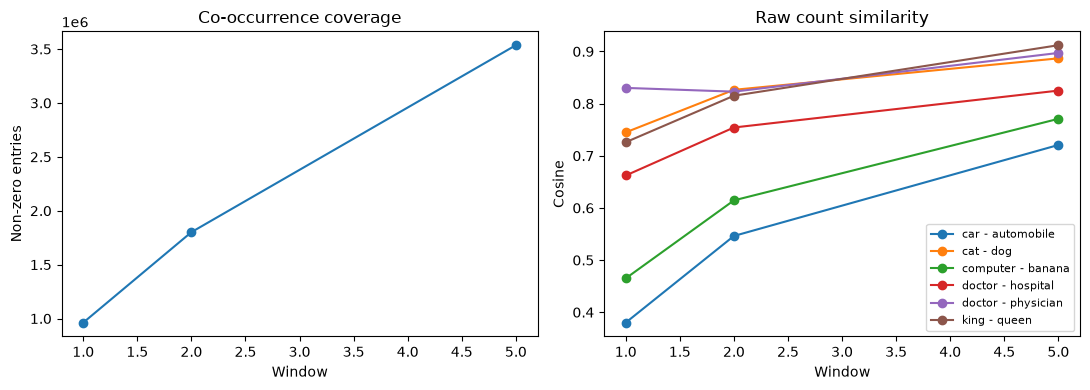


Nhận xét theo kết quả:
- Vocabulary cố định ở 5,003 từ; window chỉ thay đổi counts và nnz.
- nnz tăng từ 962,245 ở window 1 lên 3,535,674 ở window 5.
- Vocabulary đầy đủ và vocabulary chọn cho ma trận khác nhau; đây là giới hạn tài nguyên đã công bố.


In [2]:
documents = load_corpus(DATA_PATH, MAX_DOCUMENTS)
sentences = [sentence for document in documents for sentence in document]
word_counts = Counter(word for sentence in sentences for word in sentence)
vocabulary = build_vocabulary(sentences, min_count=5, max_size=5000)
vocabulary = sorted(set(vocabulary) | {word for word in FOCUS if word_counts[word] >= 5})
word_id = {word: i for i, word in enumerate(vocabulary)}
show_table(pd.DataFrame([
    {"Statistic": "Documents", "Value": len(documents)},
    {"Statistic": "Sentences", "Value": len(sentences)},
    {"Statistic": "Tokens", "Value": sum(word_counts.values())},
    {"Statistic": "Full word vocabulary", "Value": len(word_counts)},
    {"Statistic": "Co-occurrence vocabulary", "Value": len(vocabulary)},
]))
show_table(pd.DataFrame([{"Word": w, "Count": word_counts[w],
    "In co-occurrence vocabulary": w in word_id} for w in FOCUS]))
covered_tokens = sum(word_counts[w] for w in vocabulary)
print(f"Token coverage of co-occurrence vocabulary: {covered_tokens/sum(word_counts.values()):.2%}")
cooc_matrices, cooc_rows, cooc_pairs = {}, [], []
for window in [1, 2, 5]:
    start = perf_counter()
    matrix = build_cooccurrence_matrix(sentences, vocabulary, window)
    seconds = perf_counter()-start
    cooc_matrices[window] = matrix
    row = {"Window": window, "Vocabulary": len(vocabulary),
        "Rows": matrix.shape[0], "Columns": matrix.shape[1],
        "Non-zero": matrix.nnz, "Density (%)": 100*matrix.nnz/matrix.shape[0]**2,
        "Total counts": int(matrix.sum()), "Build seconds": seconds,
        "CSR MiB": (matrix.data.nbytes+matrix.indices.nbytes+matrix.indptr.nbytes)/2**20}
    cooc_rows.append(row)
    add_result("cooccurrence_stats", "10", "Raw co-occurrence", window=window,
        score=matrix.nnz, training_seconds=seconds, notes=json.dumps(row))
    for first, second in PAIRS:
        value = cosine_similarity(matrix.getrow(word_id[first]), matrix.getrow(word_id[second])) if (
            first in word_id and second in word_id) else np.nan
        cooc_pairs.append({"Pair": first+" - "+second, "Window": window, "Cosine": value})
        add_result("similarity", "10", "Raw co-occurrence", window=window,
                   word=first, other_word=second, score=value)
cooc_summary = pd.DataFrame(cooc_rows)
cooc_similarity = pd.DataFrame(cooc_pairs).pivot(index="Pair", columns="Window", values="Cosine")
show_table(cooc_summary)
show_table(cooc_similarity.reset_index())
cooc_neighbors = []
for window, matrix in cooc_matrices.items():
    if "doctor" in word_id:
        for rank, (neighbor, score) in enumerate(most_similar("doctor", matrix, vocabulary, 5), 1):
            cooc_neighbors.append({"Window": window, "Query": "doctor",
                                   "Rank": rank, "Neighbor": neighbor, "Cosine": score})
            add_result("cooccurrence_neighbor", "10", "Raw co-occurrence", window=window,
                       word="doctor", candidate=neighbor, rank=rank, score=score)
show_table(pd.DataFrame(cooc_neighbors))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cooc_summary["Window"], cooc_summary["Non-zero"], marker="o")
axes[0].set(xlabel="Window", ylabel="Non-zero entries", title="Co-occurrence coverage")
for pair, row in cooc_similarity.iterrows():
    axes[1].plot(row.index, row.values, marker="o", label=pair)
axes[1].set(xlabel="Window", ylabel="Cosine", title="Raw count similarity")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
note(f"Vocabulary cố định ở {len(vocabulary):,} từ; window chỉ thay đổi counts và nnz.",
     f"nnz tăng từ {cooc_rows[0]['Non-zero']:,} ở window 1 lên {cooc_rows[-1]['Non-zero']:,} ở window 5.",
     "Vocabulary đầy đủ và vocabulary chọn cho ma trận khác nhau; đây là giới hạn tài nguyên đã công bố.")

### Thảo luận Experiment 1

Window rộng bổ sung cặp ở xa hơn nên tổng count và nnz không giảm, nhưng cosine từng cặp không nhất thiết tăng.
Raw counts có thể làm từ khác nghĩa gần nhau vì cùng đi với từ phổ biến. Cần context để phân biệt đồng nghĩa và cùng chủ đề.

Dẫn chứng cụ thể: computer-banana ở window 5 có cosine 0,7708. Trong tích vô hướng của hai raw vectors, the đóng góp 32,05%, and 20,99%, a 15,48%; tổng ba từ khoảng 68,52% và top-10 context chiếm 91,75%. Counts tương ứng computer/banana là the=226/20, and=185/16, a=168/13. Đây là bằng chứng ảnh hưởng của context phổ biến, không chỉ suy đoán từ score.


## 11. Core implementation và kiểm tra quy ước

Bốn hàm tự cài đặt trong cooccurrence.py. Minh họa bằng corpus mục 5, khác bài tính tay mục 6.


 Word  cat  dog  eats  likes  fish  milk  meat
  cat    0    0     1      1     0     0     0
  dog    0    0     1      1     0     0     0
 eats    1    1     0      0     1     0     1
likes    1    1     0      0     1     1     0
 fish    0    0     1      1     0     0     0
 milk    0    0     0      1     0     0     0
 meat    0    0     1      0     0     0     0
Most similar to cat: [('dog', 0.9999999999999998), ('fish', 0.9999999999999998), ('meat', 0.7071067811865475), ('milk', 0.7071067811865475)]
Core checks passed: symmetry, counts, cosine, OOV spacing, sentence boundaries, self exclusion.


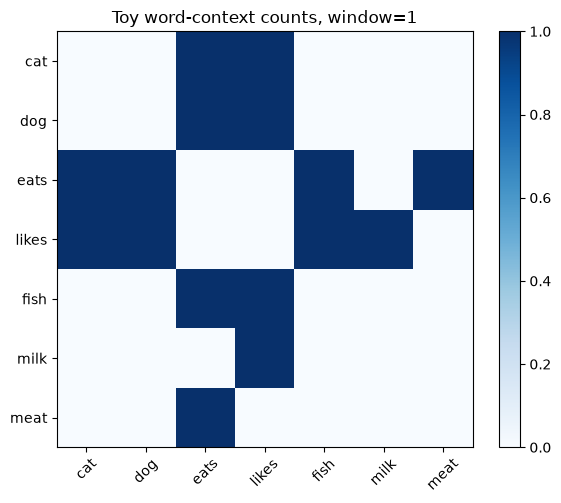

In [3]:
toy = [s.split() for s in ["the cat eats fish", "the cat likes milk",
                          "the dog eats meat", "the dog likes fish"]]
toy_vocab = ["cat", "dog", "eats", "likes", "fish", "milk", "meat"]
toy_matrix = build_cooccurrence_matrix(toy, toy_vocab, window=1)
show_table(pd.DataFrame(toy_matrix.toarray(), index=toy_vocab,
                       columns=toy_vocab).rename_axis("Word").reset_index())
print("Most similar to cat:", most_similar("cat", toy_matrix, toy_vocab, 5))
assert (toy_matrix != toy_matrix.T).nnz == 0
assert toy_matrix[0, 2] == 1 and toy_matrix[0, 3] == 1
assert abs(cosine_similarity([1, 0], [2, 0])-1) < 1e-12
assert cosine_similarity([0, 0], [2, 0]) == 0
assert np.isclose(cosine_similarity([1, 2], [2, 1]),
                  cosine_similarity(sparse.csr_matrix([[1, 2]]), sparse.csr_matrix([[2, 1]])))
assert build_cooccurrence_matrix([["cat", "unknown", "dog"]], ["cat", "dog"], 1).nnz == 0
assert build_cooccurrence_matrix([["cat"], ["dog"]], ["cat", "dog"], 1).nnz == 0
assert most_similar("cat", toy_matrix, toy_vocab, 1)[0][0] == "dog"
print("Core checks passed: symmetry, counts, cosine, OOV spacing, sentence boundaries, self exclusion.")
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(toy_matrix.toarray(), cmap="Blues")
ax.set_xticks(range(len(toy_vocab)), toy_vocab, rotation=45)
ax.set_yticks(range(len(toy_vocab)), toy_vocab)
ax.set_title("Toy word-context counts, window=1")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

### Thảo luận implementation

Cat và dog có vector giống nhau vì cùng đứng cạnh eats và likes trong corpus minh họa.
Cosine đo hướng vector; hai vector khác độ lớn vẫn có thể có cosine bằng 1.
Cosine được quy định bằng 0 khi có vector zero; most_similar loại query và vector zero.


## 12. Từ ma trận lớn đến biểu diễn ít chiều


In [4]:
show_table(pd.DataFrame([{"Vocabulary": size, "Entries": size**2,
    "Dense float32 GiB": size**2*4/2**30} for size in [len(vocabulary), 100_000]]))
print("CSR lưu các ô khác 0 và chỉ mục; nnz vẫn có thể rất lớn khi window rộng.")

 Vocabulary     Entries  Dense float32 GiB
       5003    25030009             0.0932
     100000 10000000000            37.2529
CSR lưu các ô khác 0 và chỉ mục; nnz vẫn có thể rất lớn khi window rộng.


### Thảo luận

Vocabulary 100.000 tạo 10 tỷ ô; dense float32 cần khoảng 37,25 GiB chỉ cho dữ liệu.
Sparse giảm bộ nhớ nhưng không loại bỏ số chiều lớn. Embedding ít chiều tiết kiệm hơn, nhưng việc nén có thể mất thông tin.

## 13. Neural word embeddings

Co-occurrence mô tả count trực tiếp; Word2Vec học vector dense qua bài toán dự đoán.
Vector gần nhau là pattern thống kê, không phải bằng chứng model hiểu như con người.

## 14. CBOW

Input: các từ context; target: từ trung tâm. Context vectors được tổng hợp để dự đoán target.

## 15. Skip-gram

Input: từ trung tâm; target: từng từ context. Hai objective khác nhau ở hướng dự đoán.

## 16. Bài tập tạo training examples

Phần liệt kê training pairs bằng tay nằm trong calculations.md.


## 17. Experiment 2 - Word2Vec

CBOW baseline: dimension 100, window 5, min_count 2, epochs 10, negative sampling 5. Thêm Skip-gram cùng cấu hình. Workers=1, seed/hash cố định, shrink_windows=False. Không dùng pretrained vectors.


Tài liệu API: [Gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html).

In [5]:
models, model_stats = {}, []
def get_model(dimension=100, window=5, sg=0):
    key = (dimension, window, sg)
    if key not in models:
        model, seconds = train_model(sentences, vector_size=dimension, window=window,
            sg=sg, epochs=EPOCHS, min_count=MIN_COUNT, seed=SEED)
        models[key] = model
        name = "Skip-gram" if sg else "CBOW"
        row = {"Model": name, "Dimension": dimension, "Window": window,
            "Vocabulary": len(model.wv), "Min count": MIN_COUNT, "Epochs": EPOCHS,
            "Negative samples": 5, "Workers": 1, "Seed": SEED,
            "Training seconds": seconds, "Weights MiB": parameter_bytes(model)/2**20}
        model_stats.append(row)
        add_result("training", "17/19/20", name, window=window, vector_size=dimension,
            training_seconds=seconds, model_bytes=parameter_bytes(model),
            notes=f"vocabulary={len(model.wv)}; sample=0.001; shrink_windows=False; workers=1; seed={SEED}; hash=sha256")
        print(f"Trained {name}, dimension={dimension}, window={window}: {seconds:.1f}s; vocabulary={len(model.wv):,}")
    return models[key]

baseline = get_model()
skipgram = get_model(sg=1)
show_table(pd.DataFrame(model_stats))
objective_rows = []
for first, second in PAIRS:
    for name, model in [("CBOW", baseline), ("Skip-gram", skipgram)]:
        value = safe_similarity(model, first, second)
        objective_rows.append({"Pair": first+" - "+second, "Objective": name, "Cosine": value})
        add_result("similarity", "17", name, window=5, vector_size=100,
                   word=first, other_word=second, score=value)
objective_table = pd.DataFrame(objective_rows).pivot(index="Pair", columns="Objective", values="Cosine")
show_table(objective_table.reset_index())
note(f"Vocabulary Word2Vec có {len(baseline.wv):,} từ, khác co-occurrence do min_count và giới hạn từ khác nhau.",
     "Thời gian gồm build vocabulary và training; weights MiB tính hai ma trận trọng số, không phải kích thước file model.",
     "Mỗi cấu hình mới chỉ train một lần; baseline được dùng lại trong các thí nghiệm sau.")

Trained CBOW, dimension=100, window=5: 48.1s; vocabulary=55,084


Trained Skip-gram, dimension=100, window=5: 233.5s; vocabulary=55,084
    Model  Dimension  Window  Vocabulary  Min count  Epochs  Negative samples  Workers  Seed  Training seconds  Weights MiB
     CBOW        100       5       55084          2      10                 5        1    42           48.0736      42.0258
Skip-gram        100       5       55084          2      10                 5        1    42          233.5171      42.0258
              Pair   CBOW  Skip-gram
  car - automobile 0.3362     0.6402
         cat - dog 0.5781     0.5877
 computer - banana 0.0252     0.0648
 doctor - hospital 0.5309     0.5264
doctor - physician 0.7269     0.6405
      king - queen 0.6364     0.6119

Nhận xét theo kết quả:
- Vocabulary Word2Vec có 55,084 từ, khác co-occurrence do min_count và giới hạn từ khác nhau.
- Thời gian gồm build vocabulary và training; weights MiB tính hai ma trận trọng số, không phải kích thước file model.
- Mỗi cấu hình mới chỉ train một lần; baseline được dùng lại t

### Thảo luận Word2Vec

CBOW dự đoán từ trung tâm từ context, Skip-gram dự đoán context từ từ trung tâm; cả hai dùng negative sampling.
Similarity giữa objective có thể khác do mục tiêu tối ưu và động lực học khác nhau. Sáu cặp từ chưa đủ để kết luận objective nào tốt hơn nói chung.

Trong lần chạy này, Skip-gram mất 233,52s so với CBOW 48,07s. Car-automobile tăng từ 0,3362 (CBOW) lên 0,6402 (Skip-gram), nhưng doctor-physician giảm từ 0,7269 xuống 0,6405. Sáu cặp cho phản ứng khác nhau, chưa đủ để xếp hạng objective tổng quát.


## 18. Inspect embeddings và bằng chứng corpus

Top-5 cho bảy từ trong đề; kèm tần suất và shared context thực tế. Evidence window 5, lọc stopwords chỉ ở cột dẫn chứng. Counts trước/sau dấu / thuộc query/neighbor.


In [6]:
neighbor_rows = []
for word in PROBES:
    if word not in baseline.wv:
        neighbor_rows.append({"Word": word, "Rank": 0, "Neighbor": "", "Cosine": np.nan})
        continue
    for rank, (neighbor, score) in enumerate(baseline.wv.most_similar(word, topn=5), 1):
        neighbor_rows.append({"Word": word, "Rank": rank, "Neighbor": neighbor, "Cosine": float(score)})
evidence_words = set(FOCUS) | {row["Neighbor"] for row in neighbor_rows if row["Neighbor"]}
profiles, snippets = context_evidence(sentences, evidence_words, window=5)
for row in neighbor_rows:
    word, neighbor = row["Word"], row["Neighbor"]
    row["Query count"] = word_counts[word]
    row["Neighbor count"] = word_counts[neighbor]
    row["Shared context (query/neighbor)"] = shared_context(word, neighbor, profiles) if neighbor else "OOV"
    add_result("nearest_neighbor", "18", "CBOW", window=5, vector_size=100,
        word=word, candidate=neighbor, rank=row["Rank"], score=row["Cosine"],
        notes=row["Shared context (query/neighbor)"])
neighbor_table = pd.DataFrame(neighbor_rows)
for word in PROBES:
    print("\n"+word+":")
    show_table(neighbor_table[neighbor_table["Word"] == word])
    for snippet in snippets.get(word, []):
        print("Corpus snippet:", snippet)
doctor_rows = neighbor_table[neighbor_table["Word"] == "doctor"]
if len(doctor_rows):
    first = doctor_rows.iloc[0]
    note(f"Neighbor đầu của doctor là {first['Neighbor']} (cosine={first['Cosine']:.4f}).",
         "Shared context là bằng chứng phân bố; snippet giúp kiểm tra chủ đề và nhiễu cụ thể.",
         "Context chung không tự chứng minh đồng nghĩa hoặc nguyên nhân duy nhất của similarity.")


doctor:
  Word  Rank     Neighbor  Cosine  Query count  Neighbor count                                Shared context (query/neighbor)
doctor     1    physician  0.7269          264              86   your(81/25), care(9/13), health(8/5), may(8/5), medical(5/6)
doctor     2      surgeon  0.6933          264             117    your(81/25), eye(18/20), should(9/9), ask(6/6), lasik(6/22)
doctor     3      dentist  0.6653          264              49 your(81/20), may(8/5), about(12/4), visit(6/4), important(3/3)
doctor     4   medication  0.6533          264              87        may(8/6), your(81/5), about(12/3), any(5/3), order(7/3)
doctor     5 veterinarian  0.6501          264              20    your(81/7), being(2/2), call(2/2), consult(8/2), visit(6/2)
Corpus snippet: h division deposed that having sent for the doctor he gave orders to prevent any persons leaving
Corpus snippet: vital component of the definition of a good doctor

hospital:
    Word  Rank Neighbor  Cosine  Query count

### Tại sao các từ gần doctor?

Xem shared contexts và câu trích từ corpus: các từ có thể cùng xuất hiện trong văn bản y tế, nghề nghiệp, chức danh hoặc tên người.
Neighbor có thể cùng chủ đề mà không đồng nghĩa. Count thấp và web nhiễu cũng có thể tạo kết quả bất ngờ; cần bằng chứng thay vì chỉ nói model học semantic similarity.

Doctor-physician đạt 0,7269 với context chung care, health, medical; đây là dẫn chứng liên hệ nghề y. Football-replica đạt 0,7886 với context football/shirt/kits/replica lặp nhiều, cho thấy corpus web thương mại có thể tác động mạnh đến neighbors. Patient cũng xuất hiện với nghĩa tính từ trong câu 'be patient work hard and stay focused', minh họa polysemy.


## 19. Experiment 3 - Context window

CBOW dimension 100, window 2/5/10. Giữ corpus, min_count, epochs, seed và các tham số khác cố định.


Trained CBOW, dimension=100, window=2: 43.8s; vocabulary=55,084


Trained CBOW, dimension=100, window=10: 53.1s; vocabulary=55,084
              Pair      2      5      10
  car - automobile 0.4728 0.3362  0.3372
         cat - dog 0.6644 0.5781  0.5980
 computer - banana 0.1506 0.0252 -0.1686
 doctor - hospital 0.4700 0.5309  0.5809
doctor - physician 0.7730 0.7269  0.8054
      king - queen 0.7294 0.6364  0.6115


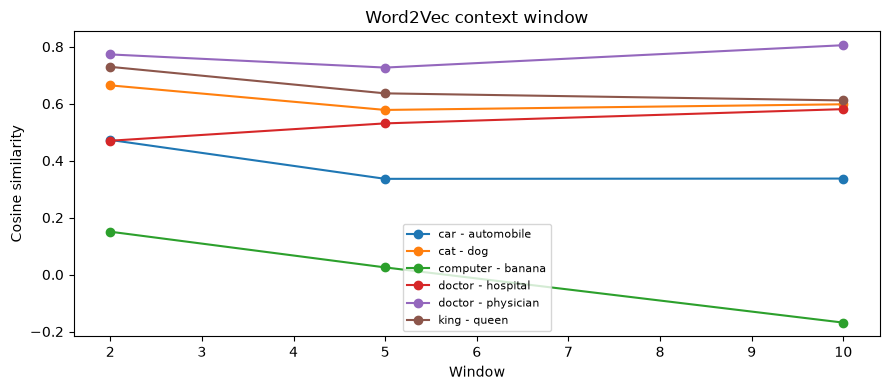


Nhận xét theo kết quả:
- 2 cặp tăng và 4 cặp giảm cosine khi window 2 -> 10.
- Cosine tăng không tương đương chất lượng tăng; cần loại quan hệ mong đợi và nhiệm vụ đánh giá.


In [7]:
window_rows = []
for window in [2, 5, 10]:
    model = get_model(window=window)
    for first, second in PAIRS:
        value = safe_similarity(model, first, second)
        window_rows.append({"Pair": first+" - "+second, "Window": window, "Cosine": value})
        add_result("similarity", "19", "CBOW", window=window, vector_size=100,
                   word=first, other_word=second, score=value)
window_table = pd.DataFrame(window_rows).pivot(index="Pair", columns="Window", values="Cosine")
show_table(window_table.reset_index())
fig, ax = plt.subplots(figsize=(9, 4))
for pair, row in window_table.iterrows():
    ax.plot(row.index, row.values, marker="o", label=pair)
ax.set(xlabel="Window", ylabel="Cosine similarity", title="Word2Vec context window")
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()
changes = window_table[10]-window_table[2]
note(f"{int((changes > 0).sum())} cặp tăng và {int((changes < 0).sum())} cặp giảm cosine khi window 2 -> 10.",
     "Cosine tăng không tương đương chất lượng tăng; cần loại quan hệ mong đợi và nhiệm vụ đánh giá.")

### Window lớn hơn có luôn tốt hơn không?

Không. Window nhỏ tập trung quan hệ cục bộ; window rộng thêm thông tin chủ đề và cả nhiễu.
Sáu cặp và một seed chưa phải benchmark tổng quát. Raw counts và Word2Vec khác cách tạo vector nên không so trực tiếp hai mức cosine như cùng một thước đo chất lượng.

Doctor-physician tăng từ 0,7730 ở window 2 lên 0,8054 ở window 10, trong khi king-queen giảm 0,7294 -> 0,6115. Không có cải thiện đồng loạt; cosine của cặp không liên quan computer-banana còn chuyển từ 0,1506 sang -0,1686.


## 20. Experiment 4 - Embedding dimension

CBOW window 5, dimension 50/100/300. Đo thời gian, bytes ma trận trọng số, similarity, analogy và downstream search.
Downstream: 12 tài liệu minh họa, 4 query, nhãn chủ đề định trước; không phải gold annotations của C4.
MRR đo vị trí tài liệu đúng đầu tiên; nDCG@3/P@3 đo top-3. Một lần chạy mỗi cấu hình; không coi đây là benchmark tổng quát.


### Dữ liệu của phép thử retrieval nhỏ

Mỗi query có ba tài liệu đúng theo nhãn chủ đề. Bộ dữ liệu nhân tạo được công khai dưới đây để giải thích cách tính MRR, P@3 và nDCG@3.

| Chủ đề | Tài liệu |
|---|---|
| medical | The physician provides therapy for patients suffering from disease. |
| medical | A hospital offers clinical care and medicine for sick people. |
| medical | Doctors diagnose illness and help patients recover. |
| sports | The soccer team scored a goal and won the game at the stadium. |
| sports | Players compete in a football league tournament. |
| sports | A coach trains athletes for the next match. |
| technology | The laptop runs applications and an operating system. |
| technology | Programmers develop programs and fix hardware problems. |
| technology | Computers use software to process digital information. |
| river | The stream flows beside the shore and through the valley. |
| river | Water moves along the river near trees and rocks. |
| river | People sit on the bank beside the river. |

| Nhãn đúng | Query |
|---|---|
| medical | medical treatment |
| sports | football match |
| technology | computer software |
| river | river bank |

Trained CBOW, dimension=50, window=5: 51.2s; vocabulary=55,084


Trained CBOW, dimension=300, window=5: 74.7s; vocabulary=55,084
 Dimension  Train seconds  Weights MiB  Analogy evaluable  Analogy Hit@1  Analogy Hit@5  Demo MRR  Demo nDCG@3  Demo P@3  Demo query coverage
        50        51.1600      21.0129                  3         0.6667         0.6667       1.0          1.0       1.0                    4
       100        48.0736      42.0258                  3         0.6667         0.6667       1.0          1.0       1.0                    4
       300        74.6799     126.0773                  3         0.6667         0.6667       1.0          1.0       1.0                    4
              Pair     50    100    300
  car - automobile 0.3420 0.3362 0.3363
         cat - dog 0.6943 0.5781 0.5796
 computer - banana 0.0610 0.0252 0.0402
 doctor - hospital 0.5711 0.5309 0.5365
doctor - physician 0.7644 0.7269 0.7201
      king - queen 0.7124 0.6364 0.6350
 Dimension             Query  MRR  nDCG@3  P@3 OOV
        50 medical treatment  1.0    

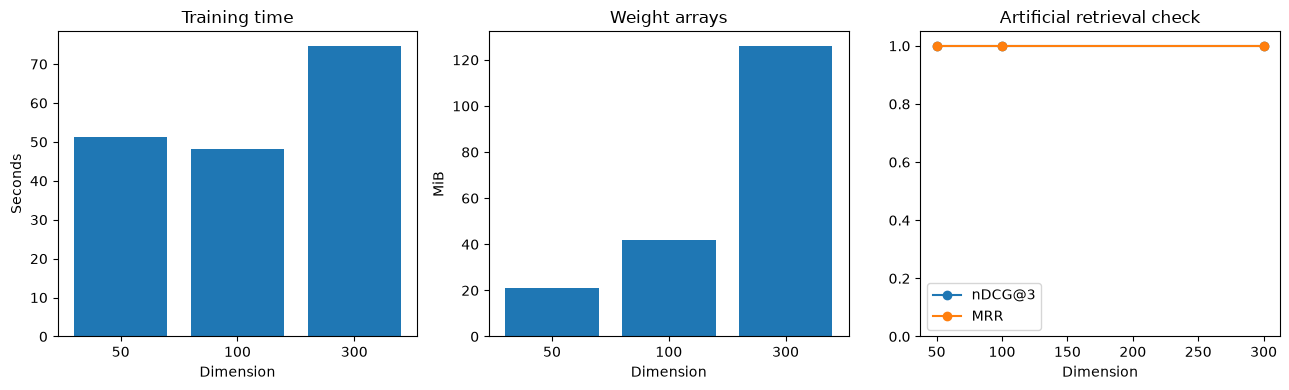


Nhận xét theo kết quả:
- Weights tăng từ 21.01 MiB ở 50 chiều lên 126.08 MiB ở 300 chiều.
- Analogy chỉ 3 câu, downstream chỉ 4 query nhân tạo; báo coverage và không coi đây là đánh giá production.
- Nhiều chiều tăng capacity nhưng cần thêm dữ liệu/tính toán; bảng thể hiện trade-off của lần chạy.


In [8]:
ANALOGIES = [
    (["king", "woman"], ["man"], "queen"),
    (["paris", "italy"], ["france"], "rome"),
    (["man", "girl"], ["boy"], "woman"),
]
dimension_rows, dimension_similarity, dimension_retrieval = [], [], []
for dimension in [50, 100, 300]:
    model = get_model(dimension=dimension)
    stat = next(r for r in model_stats if r["Dimension"] == dimension and r["Window"] == 5 and r["Model"] == "CBOW")
    tests = [analogy(model, p, n, expected) for p, n, expected in ANALOGIES]
    valid = [r for r in tests if r["status"] == "OK"]
    retrieval = retrieval_metrics(model)
    metrics = pd.DataFrame(retrieval)
    row = {"Dimension": dimension, "Train seconds": stat["Training seconds"],
        "Weights MiB": stat["Weights MiB"], "Analogy evaluable": len(valid),
        "Analogy Hit@1": np.mean([r["hit1"] for r in valid]) if valid else np.nan,
        "Analogy Hit@5": np.mean([r["hit5"] for r in valid]) if valid else np.nan,
        "Demo MRR": metrics["MRR"].mean(), "Demo nDCG@3": metrics["nDCG@3"].mean(),
        "Demo P@3": metrics["P@3"].mean(), "Demo query coverage": int(metrics["MRR"].notna().sum())}
    dimension_rows.append(row)
    for q in retrieval:
        dimension_retrieval.append({"Dimension": dimension, **q})
        for metric in ["MRR", "nDCG@3", "P@3"]:
            add_result("demo_retrieval_"+metric, "20", "CBOW", window=5, vector_size=dimension,
                       query=q["Query"], score=q[metric], notes="12 artificial docs; 4 topic queries; OOV="+q["OOV"])
    for first, second in PAIRS:
        score = safe_similarity(model, first, second)
        dimension_similarity.append({"Pair": first+" - "+second, "Dimension": dimension, "Cosine": score})
        add_result("similarity", "20", "CBOW", window=5, vector_size=dimension,
                   word=first, other_word=second, score=score)
    for test in tests:
        add_result("analogy_hit1", "20", "CBOW", window=5, vector_size=dimension,
            other_word=test["expected"], candidate=test["top1"],
            score=test["hit1"] if test["hit1"] is not None else "", notes=test["status"])
dimension_summary = pd.DataFrame(dimension_rows)
show_table(dimension_summary)
show_table(pd.DataFrame(dimension_similarity).pivot(index="Pair", columns="Dimension", values="Cosine").reset_index())
show_table(pd.DataFrame(dimension_retrieval))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].bar(dimension_summary["Dimension"].astype(str), dimension_summary["Train seconds"])
axes[0].set(title="Training time", xlabel="Dimension", ylabel="Seconds")
axes[1].bar(dimension_summary["Dimension"].astype(str), dimension_summary["Weights MiB"])
axes[1].set(title="Weight arrays", xlabel="Dimension", ylabel="MiB")
axes[2].plot(dimension_summary["Dimension"], dimension_summary["Demo nDCG@3"], marker="o", label="nDCG@3")
axes[2].plot(dimension_summary["Dimension"], dimension_summary["Demo MRR"], marker="o", label="MRR")
axes[2].set(title="Artificial retrieval check", xlabel="Dimension", ylim=(0, 1.05))
axes[2].legend()
fig.tight_layout()
plt.show()
note(f"Weights tăng từ {dimension_rows[0]['Weights MiB']:.2f} MiB ở 50 chiều lên {dimension_rows[-1]['Weights MiB']:.2f} MiB ở 300 chiều.",
     "Analogy chỉ 3 câu, downstream chỉ 4 query nhân tạo; báo coverage và không coi đây là đánh giá production.",
     "Nhiều chiều tăng capacity nhưng cần thêm dữ liệu/tính toán; bảng thể hiện trade-off của lần chạy.")

### Dimension lớn có chắc tốt hơn không?

Không. Dimension tăng làm trọng số lớn hơn khi vocabulary cố định; thời gian còn phụ thuộc máy.
Similarity, analogy và retrieval có thể phản ứng khác nhau. Cần nhiệm vụ phù hợp, tập đánh giá lớn hơn và nhiều seed để kết luận.

Ở 50/100/300 chiều, weights lần lượt khoảng 21,01/42,03/126,08 MiB; analogy Hit@1 đều 2/3. Mini search đạt MRR, nDCG@3 và P@3 bằng 1 cho mọi cấu hình: bài kiểm tra quá dễ, không phân biệt được dimension và không chứng minh model chất lượng cao trên corpus thật. Thời gian 50 chiều 51,16s hơi cao hơn 100 chiều 48,07s ở phép đo đơn; không suy ra đường thời gian đơn điệu từ một lần chạy.


## 21. Evaluation - Word similarity

Xếp hạng các cặp trong đề. Kỳ vọng định tính là bản nháp của AI, không phải nhãn đánh giá độc lập.


In [9]:
pair_rows = [{"Pair": first+" - "+second,
              "Cosine": safe_similarity(baseline, first, second),
              "First count": word_counts[first], "Second count": word_counts[second]}
             for first, second in PAIRS[:5]]
pair_ranking = pd.DataFrame(pair_rows).sort_values("Cosine", ascending=False, na_position="last").reset_index(drop=True)
pair_ranking.insert(0, "Rank", np.arange(1, len(pair_ranking)+1))
show_table(pair_ranking)
for row in pair_ranking.to_dict("records"):
    first, second = row["Pair"].split(" - ")
    add_result("ranked_similarity", "21", "CBOW", window=5, vector_size=100,
               word=first, other_word=second, rank=row["Rank"], score=row["Cosine"])
note("Kỳ vọng: doctor-physician và car-automobile gần nghĩa; cat-dog cùng nhóm; computer-banana khác chủ đề.",
     "King-queen có quan hệ giới tính/chức danh, không hoàn toàn đồng nghĩa.",
     f"Cặp đứng đầu là {pair_ranking.iloc[0]['Pair']}; kiểm tra frequency/context nếu rank khác intuition.")

 Rank               Pair  Cosine  First count  Second count
    1 doctor - physician  0.7269          264            86
    2       king - queen  0.6364          311           189
    3          cat - dog  0.5781          213           428
    4   car - automobile  0.3362         1111            20
    5  computer - banana  0.0252          622            42

Nhận xét theo kết quả:
- Kỳ vọng: doctor-physician và car-automobile gần nghĩa; cat-dog cùng nhóm; computer-banana khác chủ đề.
- King-queen có quan hệ giới tính/chức danh, không hoàn toàn đồng nghĩa.
- Cặp đứng đầu là doctor - physician; kiểm tra frequency/context nếu rank khác intuition.


### Thảo luận similarity

Cosine có thể phản ánh chủ đề, cấu trúc hoặc đồng nghĩa. Word2Vec không có trục riêng chỉ đo đồng nghĩa.
Từ ít quan sát dễ có vector chưa ổn định. Score/rank là kết quả định lượng; intuition là điểm đối chiếu.


## 22. Evaluation - Word analogy

Top-5; loại từ input khỏi candidates theo API. Báo Hit@1, Hit@5, rank trong top-5 và OOV.


In [10]:
analogy_summary, analogy_candidates = [], []
for positive, negative, expected in ANALOGIES:
    expression = " + ".join(positive)+" - "+" - ".join(negative)
    result = analogy(baseline, positive, negative, expected)
    analogy_summary.append({"Expression": expression, "Expected": expected,
        "Top 1": result["top1"], "Expected rank in top-5": result["rank"],
        "Hit@1": result["hit1"], "Hit@5": result["hit5"], "Status": result["status"]})
    for rank, (candidate, score) in enumerate(result["candidates"], 1):
        analogy_candidates.append({"Expression": expression, "Rank": rank, "Candidate": candidate, "Cosine": score})
        add_result("analogy_candidate", "22", "CBOW", window=5, vector_size=100,
                   query=expression, other_word=expected, candidate=candidate, rank=rank, score=score)
show_table(pd.DataFrame(analogy_summary))
show_table(pd.DataFrame(analogy_candidates))
valid_analogies = [r for r in analogy_summary if r["Status"] == "OK"]
note(f"Đánh giá được {len(valid_analogies)}/{len(ANALOGIES)} phép toán; Hit@1={np.mean([r['Hit@1'] for r in valid_analogies]) if valid_analogies else np.nan:.3f}.",
     "Rank trống khi expected không nằm trong top-5; không phải full-vocabulary rank.",
     "Analogy đúng là pattern trong vector space, không chứng minh hiểu quan hệ như con người.")

            Expression Expected Top 1  Expected rank in top-5  Hit@1  Hit@5 Status
    king + woman - man    queen queen                     1.0      1      1     OK
paris + italy - france     rome opera                     NaN      0      0     OK
      man + girl - boy    woman woman                     1.0      1      1     OK
            Expression  Rank Candidate  Cosine
    king + woman - man     1     queen  0.6225
    king + woman - man     2     harry  0.5996
    king + woman - man     3   fincham  0.5683
    king + woman - man     4       duo  0.5511
    king + woman - man     5     alice  0.5489
paris + italy - france     1     opera  0.6939
paris + italy - france     2   tuscany  0.6788
paris + italy - france     3  festival  0.6762
paris + italy - france     4   theatre  0.6658
paris + italy - france     5    palace  0.6646
      man + girl - boy     1     woman  0.7228
      man + girl - boy     2    person  0.5993
      man + girl - boy     3     satan  0.5676
      man 

### Tại sao vector arithmetic có thể biểu hiện quan hệ?

Các từ có cách dùng liên quan có thể tạo hướng dịch chuyển tương tự trong không gian vector.
Quan hệ không bắt buộc tuyến tính; corpus nhỏ có thể thiếu ví dụ và vector static có thể trộn nhiều nghĩa.

## 23. Bài tính analogy

Phép tính vector giả định nằm trong calculations.md, độc lập với kết quả model.

Baseline trả queen cho king+woman-man và woman cho man+girl-boy. Paris+Italy-France trả opera, không có rome trong top-5; rome vẫn có trong vocabulary (49 token), nên đây không phải OOV. Cần phân tích corpus/context địa danh và chủ đề trước khi kết luận nguyên nhân của phép analogy thất bại.


## 24. Application - Semantic search

Query medical treatment; query/document vector là trung bình vector từ, bỏ stopwords ở bước search và chuẩn hóa L2.
So top-5 với TF-IDF lexical trên cùng 10k documents. Đây là search in-sample trên corpus huấn luyện embedding.
Mini downstream có nhãn chủ đề ở mục 20 khác với search corpus thật; không tự gán accuracy cho top-5 C4.


       Method  Rank  Document  Score  Embedding coverage  Exact query hits                                                                                                                                                                                                                                                                                                                                                                              Snippet
Word2Vec mean     1      9420 0.8440              0.8500                 1                                                                                                                                                                                           treatment of bleeding problems without removal of uterus tcre etc screening and treatment for cancer of uterus cervix and ovary breast lump and cancer screening mammography and treatment
Word2Vec mean     2       280 0.7507              1.0000                 0                              

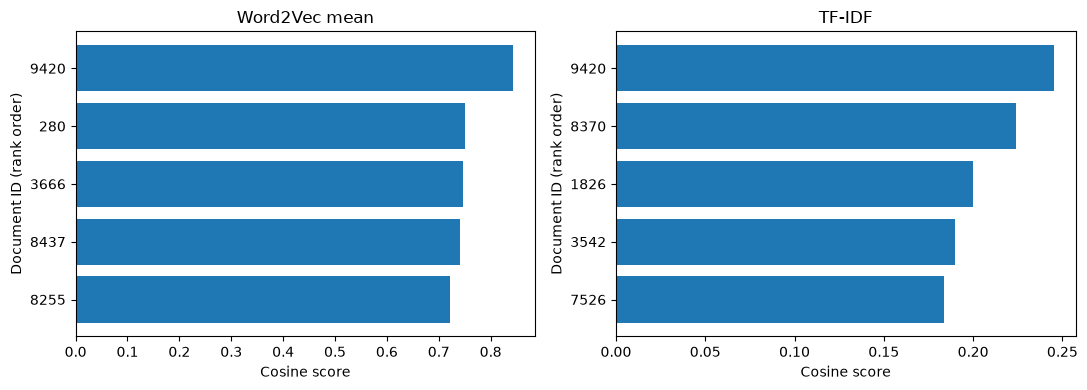

Query word       Neighbor  Cosine
   medical         dental  0.6849
   medical      diagnosis  0.6563
   medical     counseling  0.6530
   medical        nursing  0.6507
   medical rehabilitation  0.6490
 treatment        surgery  0.7612
 treatment     treatments  0.7539
 treatment       surgical  0.7278
 treatment      diagnosis  0.7270
 treatment       diabetes  0.7081

Nhận xét theo kết quả:
- Hai danh sách top-5 có 1 documents chung.
- Mean embedding có thể tìm cùng chủ đề dù thiếu từ query, nhưng bỏ qua thứ tự và bị từ chung chi phối.
- TF-IDF ưu tiên khớp từ trực tiếp; đọc snippet/context để đánh giá relevance, không đồng nhất score hai phương pháp.


In [11]:
query = "medical treatment"
doc_vectors, doc_coverage = document_vectors(documents, baseline)
semantic, missing = semantic_scores(query, doc_vectors, baseline)
lexical_matrix, lexical_word_id, idf = lexical_index(documents, baseline.wv.index_to_key)
lexical = lexical_scores(query, lexical_matrix, lexical_word_id, idf)
search_rows = []
for method, scores in [("Word2Vec mean", semantic), ("TF-IDF", lexical)]:
    order = sorted(range(len(scores)), key=lambda i: (-float(scores[i]), i))[:5]
    for rank, index in enumerate(order, 1):
        tokens = [word for sentence in documents[index] for word in sentence]
        row = {"Method": method, "Rank": rank, "Document": index,
            "Score": float(scores[index]), "Embedding coverage": doc_coverage[index],
            "Exact query hits": sum(word in tokens for word in query.split()),
            "Snippet": " ".join(tokens[:55])}
        search_rows.append(row)
        add_result("search", "24", "CBOW" if method == "Word2Vec mean" else "TF-IDF",
            window=5 if method == "Word2Vec mean" else "", vector_size=100 if method == "Word2Vec mean" else "",
            query=query, candidate=str(index), rank=rank, score=row["Score"],
            notes=f"method={method}; coverage={doc_coverage[index]:.4f}; exact_query_terms={row['Exact query hits']}; snippet={row['Snippet']}")
show_table(pd.DataFrame(search_rows))
print("Query OOV:", missing or "None")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, method in zip(axes, ["Word2Vec mean", "TF-IDF"]):
    subset = [row for row in search_rows if row["Method"] == method]
    ax.barh([str(row["Document"]) for row in subset], [row["Score"] for row in subset])
    ax.invert_yaxis()
    ax.set(title=method, xlabel="Cosine score", ylabel="Document ID (rank order)")
fig.tight_layout()
plt.show()
show_table(pd.DataFrame([{"Query word": word, "Neighbor": neighbor, "Cosine": float(score)}
    for word in query.split() if word in baseline.wv
    for neighbor, score in baseline.wv.most_similar(word, topn=5)]))
sem_ids = {r["Document"] for r in search_rows if r["Method"] == "Word2Vec mean"}
lex_ids = {r["Document"] for r in search_rows if r["Method"] == "TF-IDF"}
note(f"Hai danh sách top-5 có {len(sem_ids & lex_ids)} documents chung.",
     "Mean embedding có thể tìm cùng chủ đề dù thiếu từ query, nhưng bỏ qua thứ tự và bị từ chung chi phối.",
     "TF-IDF ưu tiên khớp từ trực tiếp; đọc snippet/context để đánh giá relevance, không đồng nhất score hai phương pháp.")

### Thảo luận semantic search

Embedding hỗ trợ các từ có cách dùng gần nhau; TF-IDF giữ tín hiệu khớp từ cụ thể.
Mean vector là baseline đơn giản: tài liệu dài trộn nhiều chủ đề, phủ định và quan hệ từ bị mất.
Người đọc cần đánh giá top results; mini benchmark mục 20 chỉ là ví dụ nhỏ có nhãn chủ đề định trước.

Document 280 nằm thứ 2 theo Word2Vec với cosine 0,7507 dù không có cả medical lẫn treatment; snippet nói về pain, cancer và palliative care. Đây là ví dụ tìm chủ đề y tế qua từ liên quan. Hai top-5 chỉ chung doc 9420; chưa có relevance labels độc lập nên không tuyên bố phương pháp nào tốt hơn.


## 25. Error analysis - 3 đúng theo kỳ vọng và 3 bất ngờ

Sáu trường hợp chọn từ top-5 thật của baseline. Mỗi trường hợp có cosine, rank, expected, token/document count, shared contexts và câu trích corpus.
Đây là nhận xét định tính của bản nháp; bất ngờ không tự có nghĩa là sai. Sinh viên tự kiểm tra và hoàn thiện error_analysis.md.


In [12]:
case_specs = [
    ("Đúng theo kỳ vọng", "doctor", "physician", "Hai cách gọi nghề y"),
    ("Đúng theo kỳ vọng", "hospital", "clinic", "Hai loại cơ sở chăm sóc sức khỏe"),
    ("Đúng theo kỳ vọng", "computer", "software", "Liên quan lĩnh vực máy tính; không đồng nghĩa"),
    ("Bất ngờ", "football", "replica", "Kỳ vọng môn thể thao gần sports/baseball hơn mặt hàng"),
    ("Bất ngờ", "banana", "tikka", "Kỳ vọng gần tên trái cây hơn tên món ăn"),
    ("Bất ngờ", "hospital", "emory", "Kỳ vọng loại cơ sở, nhưng gặp tên riêng"),
]
case_words = {w for _, first, second, _ in case_specs for w in [first, second]}
extra_profiles, extra_snippets = context_evidence(sentences, case_words, window=5)
document_frequency = Counter()
football_replica_docs = Counter()
for index, document in enumerate(documents):
    document_frequency.update(case_words & {w for sentence in document for w in sentence})
    for sentence in document:
        for i, word in enumerate(sentence):
            if word == "football":
                football_replica_docs[index] += sum(
                    w == "replica" for j, w in enumerate(
                        sentence[max(0, i-5):i+6], max(0, i-5)) if j != i)
joint_total = sum(football_replica_docs.values())
dominant_doc, dominant_count = football_replica_docs.most_common(1)[0] if joint_total else (-1, 0)
analysis_rows = []
for label, first, second, expected in case_specs:
    score = safe_similarity(baseline, first, second)
    top5 = [word for word, value in baseline.wv.most_similar(first, topn=5)] if first in baseline.wv else []
    rank = top5.index(second)+1 if second in top5 else None
    if (first, second) == ("football", "replica"):
        explanation = (f"Domain bias/template: {joint_total} lần replica trong window 5 của football; "
            f"doc {dominant_doc} đóng góp {dominant_count} lần ({dominant_count/joint_total:.1%}). "
            "Context shirt/kits liên quan bán áo, không phải đồng nghĩa.")
    elif (first, second) == ("banana", "tikka"):
        explanation = (f"Tikka chỉ có {word_counts[second]} lần trong {document_frequency[second]} documents; "
            "dữ liệu học ít. Liên hệ miền nấu ăn/recipe hoặc vector chưa ổn định là giả thuyết, "
            "không thể kết luận nguyên nhân duy nhất từ cosine.")
    elif (first, second) == ("hospital", "emory"):
        explanation = (f"Emory là tên riêng, chỉ có {word_counts[second]} lần trong "
            f"{document_frequency[second]} documents. Context university/hospital có thể tạo "
            "liên hệ tổ chức; bất ngờ về loại quan hệ, không nhất thiết sai.")
    else:
        explanation = ("Context chung phù hợp quan hệ dự kiến. Đây là đánh giá định tính "
                       "của bản nháp, không phải nhãn gold độc lập.")
    row = {"Type": label, "Pair": first+" - "+second, "Observed cosine": score,
        "Top-5 rank": rank, "Expected": expected,
        "Token counts": f"{word_counts[first]}/{word_counts[second]}",
        "Document counts": f"{document_frequency[first]}/{document_frequency[second]}",
        "Evidence shared context": shared_context(first, second, extra_profiles),
        "Possible explanation": explanation}
    analysis_rows.append(row)
    add_result("error_analysis", "25", "CBOW", window=5, vector_size=100,
        word=first, other_word=second, score=score, notes=json.dumps(row, ensure_ascii=False))
show_table(pd.DataFrame(analysis_rows))
for label, first, second, expected in case_specs:
    print("\n"+label+": "+first+" - "+second)
    joint_examples = []
    for sentence in sentences:
        if first in sentence and second in sentence:
            left, right = sorted([sentence.index(first), sentence.index(second)])
            joint_examples.append(" ".join(sentence[max(0, left-5):right+6]))
            if len(joint_examples) == 2:
                break
    if joint_examples:
        for text in joint_examples:
            print("Câu có cả hai từ:", text)
    else:
        print("Không tìm thấy câu có cả hai từ; kiểm tra context riêng:")
        for word in [first, second]:
            for text in extra_snippets[word]:
                print(word+": "+text)
note(f"Football-replica cosine={safe_similarity(baseline, 'football', 'replica'):.4f}, "
     f"cao hơn football-baseball ({safe_similarity(baseline, 'football', 'baseball'):.4f}); "
     "count và snippet về shirt/replica hỗ trợ giả thuyết bias từ web bán hàng.",
     "Banana-tikka có cosine cao dù tikka ít xuất hiện và không có shared context trong window evidence; "
     "cần nhiều dữ liệu/seed hơn để kiểm tra độ ổn định.",
     "Hospital-emory là liên hệ tên tổ chức, không đồng nghĩa; ba trường hợp bất ngờ không đều là lỗi ngữ nghĩa.",
     "Sáu trường hợp là bản nháp có bằng chứng; sinh viên tự xác nhận nhận xét trong error_analysis.md.")

             Type                Pair  Observed cosine  Top-5 rank                                              Expected Token counts Document counts                                                             Evidence shared context                                                                                                                                                        Possible explanation
Đúng theo kỳ vọng  doctor - physician           0.7269           1                                   Hai cách gọi nghề y       264/86          135/54                        your(81/25), care(9/13), health(8/5), may(8/5), medical(5/6)                                                                Context chung phù hợp quan hệ dự kiến. Đây là đánh giá định tính của bản nháp, không phải nhãn gold độc lập.
Đúng theo kỳ vọng   hospital - clinic           0.7292           1                      Hai loại cơ sở chăm sóc sức khỏe      356/107          179/58                  your(15/11), health(1

### Thảo luận lỗi

Football-replica được kiểm tra bằng count và mức tập trung ở một document bán áo, thay vì chỉ nhìn score.
Banana-tikka là giả thuyết về dữ liệu ít/miền công thức nấu ăn; chưa có thử nghiệm nhiều seed để khẳng định instability.
Hospital-emory cho thấy embedding có thể học liên hệ tên tổ chức thay vì quan hệ đồng nghĩa.


## 26. Polysemy - bank

Tìm context tài chính và bờ sông trong corpus thật; báo nếu không tìm được. Cùng một vector cho mọi lần xuất hiện của bank.


In [13]:
bank_rows = []
seen_bank_domains = set()
financial = {"money", "loan", "credit", "deposit", "financial", "account", "banking", "finance"}
river_words = {"river", "shore", "stream", "water", "lake"}
for sentence in sentences:
    for i, word in enumerate(sentence):
        if word != "bank":
            continue
        local = sentence[max(0, i-12):i+13]
        for label, terms in [("Financial cue", financial), ("River cue", river_words)]:
            if label not in seen_bank_domains and set(local) & terms:
                bank_rows.append({"Context category": label, "Corpus snippet": " ".join(local),
                                  "Vector": "Same static bank vector"})
                seen_bank_domains.add(label)
    if len(seen_bank_domains) == 2:
        break
show_table(pd.DataFrame(bank_rows))
for label in ["Financial cue", "River cue"]:
    if label not in seen_bank_domains:
        print("Không tìm thấy context có cue:", label)
show_table(pd.DataFrame([{"Pair": "bank - "+word,
    "Cosine": safe_similarity(baseline, "bank", word)} for word in ["money", "river", "finance", "water"]]))
if "bank" in baseline.wv:
    print("Cosine between static bank vectors from two occurrences:",
          cosine_similarity(baseline.wv["bank"], baseline.wv["bank"]))
note("Cue chỉ dùng để chọn ví dụ; cần đọc câu để xác nhận nghĩa.",
     "Vector bank không đổi theo câu; cosine 1 giữa hai lần lấy cùng vector không nghĩa là hai nghĩa giống nhau.")

Context category                                                                     Corpus snippet                  Vector
   Financial cue their roofing problem remedied and not having to dig further in their bank account Same static bank vector
       River cue    the river the road bends to the right and follows the eastern bank of the river Same static bank vector
          Pair  Cosine
  bank - money  0.3998
  bank - river  0.0873
bank - finance  0.5773
  bank - water -0.0410
Cosine between static bank vectors from two occurrences: 0.9999999999999998

Nhận xét theo kết quả:
- Cue chỉ dùng để chọn ví dụ; cần đọc câu để xác nhận nghĩa.
- Vector bank không đổi theo câu; cosine 1 giữa hai lần lấy cùng vector không nghĩa là hai nghĩa giống nhau.


### Làm thế nào một vector biểu diễn hai nghĩa?

Static Word2Vec gộp context của bank vào một vector. Nghĩa phổ biến có thể chi phối hoặc vector trộn nhiều nghĩa.
Contextual representation tính vector theo câu nên có thể phân biệt cách dùng; chất lượng còn phụ thuộc model/dữ liệu.

## 27. Reflection - Từ Word2Vec đến Transformer

| Representation | Phụ thuộc nghĩa trong context từng lần xuất hiện? | Sparse/Dense | Một từ có nhiều vector theo câu? |
|---|---|---|---|
| TF-IDF document vector | Không mô hình hóa nghĩa từng lần xuất hiện | Sparse | Không phải word embedding theo occurrence |
| Raw co-occurrence word vector | Không, tổng hợp corpus | Sparse | Một vector cố định |
| Word2Vec | Không, static | Dense | Một vector cố định |
| Contextual embedding | Có | Dense | Có |

TF-IDF ở đây là vector tài liệu, không đồng nhất word embedding. Word-context sau giảm chiều có thể dense; raw counts đang dùng sparse.
Bank cần contextual representation vì cách dùng trong câu quyết định nghĩa; vector static không thay đổi theo câu.
Đây là bảng tham khảo; câu trả lời cá nhân nằm trong reflection.md.

## 28. AI assistance statement

- Tool: Codex.
- Purpose: hỗ trợ cài đặt mã, thực nghiệm, visualization và bản nháp nhận xét.
- Generated content: cooccurrence.py, embedding_utils.py, notebook và nhận xét dựa trên kết quả.
- Modified content: sinh viên ghi chính xác phần mình đã chỉnh.
- Verification: kiểm tra counts/cosine/window, thực thi notebook và đối chiếu results.csv.
- Phần tính tay, prediction và reflection riêng vẫn để sinh viên hoàn thiện.

Trong corpus tìm được bank account và eastern bank of the river. Baseline bank-finance đạt 0,5773, bank-river chỉ 0,0873: phù hợp giả thuyết vector chịu ảnh hưởng miền tài chính, nhưng không phải phép đo khả năng phân biệt nghĩa ở từng câu. Vector vẫn giống hệt giữa hai occurrences.


## Xuất kết quả thực nghiệm

Chỉ ghi results.csv. Model/hình không xuất thành file riêng; PNG nhúng trong output notebook.


In [14]:
result_table = pd.DataFrame(records)
result_table.to_csv(LAB_DIR / "results.csv", index=False, encoding="utf-8")
print(f"Saved {len(result_table)} records to {LAB_DIR / 'results.csv'}")
show_table(result_table.groupby("record_type").size().rename("Records").reset_index())
print("Unique trained configurations:", len(models))

Saved 206 records to D:\NLP_exercise\lab3\results.csv
          record_type  Records
    analogy_candidate       15
         analogy_hit1        9
cooccurrence_neighbor       15
   cooccurrence_stats        3
   demo_retrieval_MRR       12
   demo_retrieval_P@3       12
demo_retrieval_nDCG@3       12
       error_analysis        6
     nearest_neighbor       35
    ranked_similarity        5
               search       10
           similarity       66
             training        6
Unique trained configurations: 6
